# Monte Carlo Exploring Starts

This project implements **Monte Carlo exploring starts algorithm** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

## Setup Environment

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment, State
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

lake_grid

[['F', 'F', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

# Monte Carlo Learning: *MC Exploring Start algorithm*

- Monte Carlo Exploring Starts is a model-free reinforcement learning control algorithm used to find the optimal policy.
- It is based purely on sampled episodes (no bootstrapping).
- ***bootstrapping***:
   - an agent updates its estimates of state or action values using its own predictions, rather than relying solely on complete trajectories of experience. [more](https://milvus.io/ai-quick-reference/what-is-bootstrapping-in-rl)
   - making updates after each step rather than waiting for an episode to end.
- **Exploring start:**
  - Every state–action pair has a non-zero probability of being selected as the starting pair of an episode.
  - This guarantees that all (s, a) pairs will eventually be explored.

### Visit:
- Every time a state-action pair (S, a) appears in the episode, it is called a visit of that state-action pair.

### Types of Visit:
- **First-visit method**:
  - Update a state’s value only the first time it appears in an episode.
  - If a state appears 3 times in the same episode: $S0 → S1 → S2 → S1 → S3 → S1$
  - For state $S1$, Only use the return from its first occurrence and ignore later occurrences in that episode
  - $V(s)$ = average of returns following first visits to s
    
- **Every-visit method**:
  - Update a state’s value every time it appears in an episode.
  - If a state appears 3 times in the same episode: $S0 → S1 → S2 → S1 → S3 → S1$
  - For state $S1$, use the return from each of the 3 occurrences.
  - $V(s)$ = average of returns from all visits to s

- Drawback:
  -  In practice, exploring start is difficult to achieve. For many applications, especially those involving physical interactions with environments, it is difficult to collect episodes starting from every state-action pair.   

## Comparison with MC basic algorithm
- When to update policy:
  - In MC basic algorithm, we first collect all the episodes starting from state-action pairs and then average the return to approximate the action value.
  - The problem with this method is that the agent has to wait unti **ALL** the episodes have been collected.
  - In MC exploring starts, we use an iterative mean calculating algorithm to update the action value and policy at the end of each episode.

- Utilize episodes more efficiently:
  - In MC basic algorithm, for each episode we only consider the initial state-value pair of the episode.
  - The problem with this method is that it does not utilize the episode more efficiently.
  - In MC exploring starts, the episode also visits other state-action pairs
    
    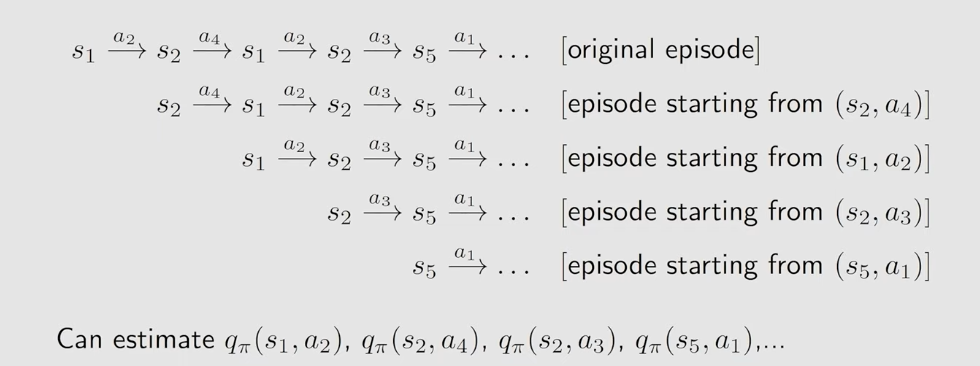

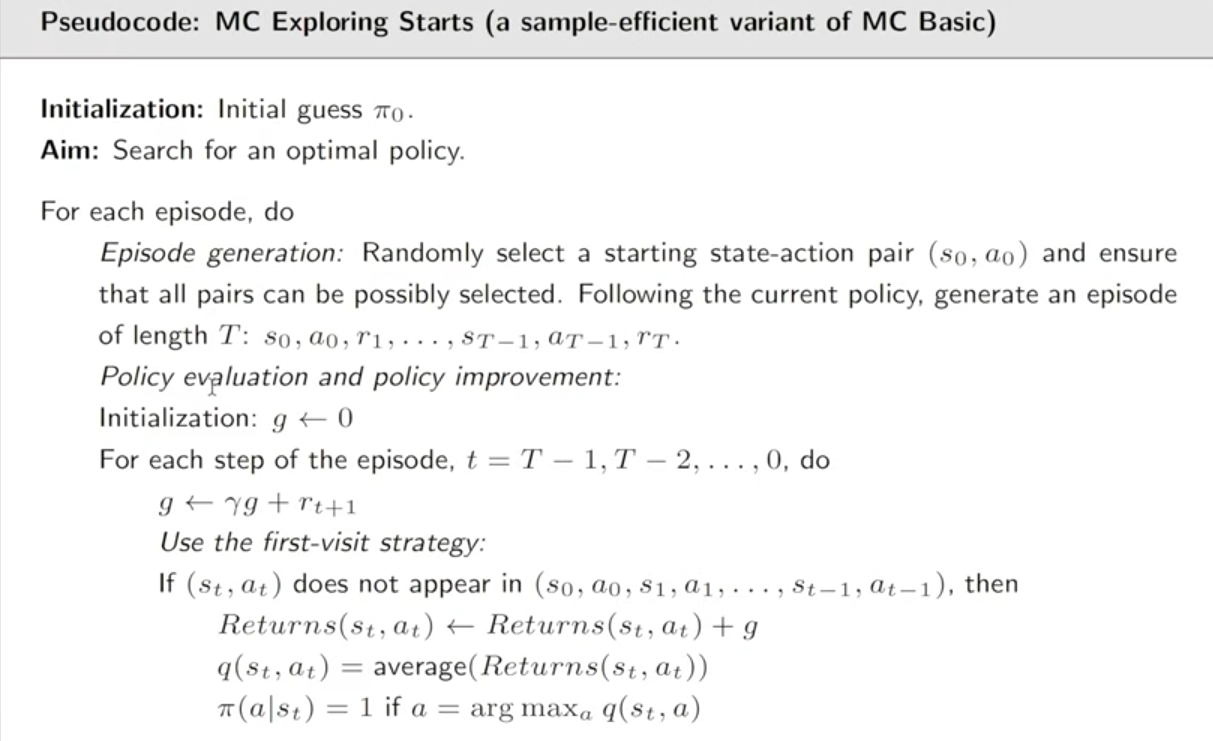

In [4]:
import random

In [5]:
def randomly_state_action_pair(state_list, action_list):
    # select element uniformly will ensure all the state, action will be selected eventually
    s = random.choice(state_list)
    a = random.choice(action_list)
    return (s, a)

In [6]:
def generate_episode(env, policy, state, action, max_step=1000, episode_idx=0, verbose=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    episode = []
    for step in range(max_step): 
        result = env.step(state, action)
        reward = result["reward"]
        episode.append((state, action, reward))
        
        prev_state = state
        state = result["new_state"]
        is_terminated = result["is_terminated"]
        action = policy[state.idx] #1D policy
    
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {state.coord}")
        elif verbose == 2:
            env.render(policy, state, episode_idx, step, reward)
            
        if is_terminated:
            break
            
    return episode

### Incremental average Formula: 

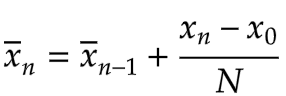

In [7]:
# In the next chapter, we will analyze the algorithm
def incremental_average(last_average, x, count):
    new_average = last_average - (last_average - x)/count
    return new_average

In [8]:
def policy_evaluation_improvement(env, policy, Q, episode, gamma, returns_count):
    visited_pair = set()
    G = 0
    
    for i in range(len(episode)-1, -1, -1): # reverse loop 
        s, a, r = episode[i]

        G = r + gamma * G
        
        # ===== first visit method ===========
        if (s.idx,a) in visited_pair:
            # do not update the Q table for the already visited (s,a) pair, 
            # because in first visit we only do it once in the given episode.
            # note that the averaging is done over episodes, not within the returns of the episode
            continue
        # ====================================
        
        returns_count[s.idx][a] += 1
        
        # (s, a) does not exist in the remaining part of the episode, so we improve the policy
        # here we  wait for episode end for the state 
        
        last_mean_g = Q[s.idx][a]
        updated_mean_g = incremental_average(last_mean_g, G, returns_count[s.idx][a])
        Q[s.idx][a] = updated_mean_g

        # ---- policy improvement -------
        policy[s.idx] = np.argmax(Q[s.idx])
        visited_pair.add((s.idx, a))
        
    return policy, Q, returns_count

In [9]:
def mc_exploring_starts_run(env, n_episodes=1000, max_step=1000, gamma=0.99, verbose=0):
    policy_history = []
    Q_history = []

    states_list = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    actions_list = list(env.action_to_idx.values())
    
    policy = np.zeros(env.n_states, dtype=np.int32)    
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)

    returns_count = np.zeros((env.n_states, env.n_actions), dtype=np.int32) 
    
    for episode_idx in range(n_episodes):
        state, action = randomly_state_action_pair(states_list,
                                                   actions_list)
        episode = generate_episode(env,
                                   policy,
                                   state, 
                                   action,
                                   max_step=max_step,
                                   episode_idx=episode_idx,
                                   verbose=verbose)
        
        policy, Q, returns_count = policy_evaluation_improvement(env,
                                                  policy.copy(),
                                                  Q,
                                                  episode,
                                                  gamma=gamma,
                                                  returns_count=returns_count)
        policy_history.append(policy.tolist())
        Q_history.append(Q.tolist())
        
    return policy, Q, policy_history, Q_history

## Execute the algorithms

In [10]:
lake_grid = [["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [11]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [12]:
frozen_lake.n_rows

4

In [13]:
policy, Q, policy_history, Q_history = mc_exploring_starts_run(frozen_lake, n_episodes=50_000, verbose=0)

In [14]:
policy

array([3, 2, 2, 1, 3, 1, 0, 1, 2, 2, 2, 0, 3, 0, 2, 3], dtype=int32)

In [15]:
Q

array([[5.9203205, 6.236764 , 6.5660105, 6.8164196],
       [6.3165164, 6.2442045, 6.9933124, 6.365302 ],
       [6.0079727, 2.2306914, 7.1708984, 6.079996 ],
       [7.263891 , 8.427354 , 7.837257 , 8.134381 ],
       [6.1223383, 6.525288 , 6.089501 , 6.602453 ],
       [5.379461 , 6.245447 , 2.0728128, 5.7865367],
       [0.       , 0.       , 0.       , 0.       ],
       [2.566135 , 8.704179 , 8.026743 , 7.4884953],
       [6.468709 , 6.1926465, 6.967599 , 6.1912613],
       [5.6923795, 2.0538192, 7.2907586, 5.9710655],
       [6.923332 , 7.636285 , 8.568189 , 2.5359375],
       [0.       , 0.       , 0.       , 0.       ],
       [4.922485 , 5.594364 , 1.7571079, 5.917103 ],
       [0.       , 0.       , 0.       , 0.       ],
       [2.4078593, 7.68472  , 8.4672785, 7.407038 ],
       [8.721268 , 9.572338 , 9.533763 , 9.823511 ]], dtype=float32)

In [16]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [17]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[3, 2, 2, 1],
       [3, 1, 0, 1],
       [2, 2, 2, 0],
       [3, 0, 2, 3]], dtype=int16)

# Render policy
Let's create a rendering function to visualize the policy clearly.

In [18]:
import pandas as pd
from IPython.display import display

In [19]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,↑,→,→,↓
1,↑,↓,🕳️,↓
2,→,→,→,🏁
3,↑,🕳️,→,↑


# Animate policy and state value history

In [20]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [21]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:]) #plotting only last 10 history
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [22]:
grid = generate_grid_randomly(5, 5, n_holes=5)
grid

[['F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'G', 'H'],
 ['S', 'H', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'H', 'H'],
 ['F', 'H', 'F', 'F', 'F']]

In [23]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

policy, Q, policy_history, Q_history = mc_exploring_starts_run(frozen_lake, n_episodes=60_000)

In [24]:
len(policy_history)

60000

In [25]:
policy

array([2, 2, 2, 1, 0, 3, 2, 2, 0, 0, 3, 0, 3, 3, 0, 3, 0, 3, 0, 0, 3, 0,
       3, 0, 0], dtype=int32)

In [26]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3,4
0,→,→,→,↓,←
1,↑,→,→,🏁,🕳️
2,🚀 ↑,🕳️,↑,↑,←
3,↑,←,↑,🕳️,🕳️
4,↑,🕳️,↑,←,←


In [27]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:])
HTML(ani.to_jshtml())